
# Предсказание возрастной категории пользователей для рекламной сети «Йети»

### 1. Цель исследования

Разработать предиктивную модель машинного обучения, способную классифицировать анонимных пользователей по возрастным группам на основе их цифрового следа (истории посещений сайтов и взаимодействия с устройствами).

### 2. Описание исследования

Заказчик проекта — IT-компания «Йети», получающая значительную часть дохода от таргетированной контекстной рекламы. Для повышения эффективности рекламных кампаний и минимизации репутационных и юридических рисков (например, показа рекламы для взрослых несовершеннолетним) алгоритмам сети требуется точное определение возраста аудитории.

Так как прямой доступ к паспортным данным пользователей отсутствует, необходимо создать инструмент, который будет анализировать поведенческие факторы (посещаемые категории сайтов, время активности, кликабельность рекламы, тип устройства) и относить пользователя к одной из пяти возрастных категорий. Результат позволит рекламодателям выходить на релевантную целевую аудиторию и рационально использовать маркетинговый бюджет.

### 3. Задачи исследования

Для достижения поставленной цели необходимо выполнить следующие шаги:

1. **Загрузка и исследовательский анализ данных (EDA):** изучение распределений, поиск пропусков, дубликатов и аномалий в разрозненных таблицах.
2. **Конструирование признаков (Feature Engineering):** написание функции для агрегации логов визитов. Расчет долей активности по категориям сайтов и времени суток для каждого `user_id`, объединение всех данных в единое признаковое пространство.
3. **Предобработка данных:** корректное разделение на обучающую и тестовую выборки строго по уникальным `user_id` (20-30% в тест) во избежание утечки данных; масштабирование числовых и кодирование категориальных признаков.
4. **Обучение моделей:** построение базовой модели (`DummyClassifier`), а также обучение `LogisticRegression` и метода опорных векторов (`SVM`) с различными ядрами.
5. **Оптимизация:** подбор гиперпараметров для архитектур с использованием кросс-валидации (со стратификацией по целевой переменной).
6. **Оценка качества:** сравнение моделей и выбор лучшей.
7. **Подготовка к внедрению:** сериализация итоговой модели и полного пайплайна предобработки (включая функцию сборки признаков) с помощью `pickle` или `joblib`, а также проверка сохраненных артефактов.

### 4. Исходные данные

Данные предоставлены в виде шести независимых csv-таблиц:

* `ds_s13_users.csv`: целевая переменная `age_category` (возрастные классы: 0: <18, 1: 18-25, 2: 26-40, 3: 41-55, 4: 56+) для каждого `user_id`.
* `ds_s13_visits.csv`: логи посещений (анонимизированные категории сайтов, время суток, даты и сессии).
* `ads_activity.csv`: показатель CTR (кликабельность рекламы) пользователя.
* `surf_depth.csv`: глубина просмотра сайтов в рамках сессии.
* `primary_device.csv`: тип основного устройства пользователя.
* `cloud_usage.csv`: флаг использования облачных технологий.

### 5. Критерий успешности исследования

* Проведено содержательное исследование и отбор признаков, обоснованные аналитикой.
* Утечка данных при предобработке и сплитовании исключена.
* Значение метрики **F1-macro** у итоговой модели составляет **не менее 0.75** как на кросс-валидации по обучающей выборке, так и на отложенной тестовой выборке.
* Полный пайплайн решения успешно сохранен в файл и готов к загрузке в промышленную эксплуатацию.

## Подготовка среды и библиотек

In [1]:
%pip install numpy pandas scikit- -q
%pip install matplotlib -q
%pip install seaborn -q
%pip install statsmodels -q
!pip3 install phik -q
!pip3 install -U scikit-learn

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import RFE
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    Normalizer,
    OneHotEncoder,
    StandardScaler
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from functools import reduce

RANDOM_STATE = 42

ERROR: Invalid requirement: 'scikit-'
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal s

## Исследовательский анализ данных

In [2]:
# Выведем информацию по каждому датафрейму через цикл:
dataframes = {
    'users': pd.read_csv('ds_s13_users.csv'),
    'visits': pd.read_csv('ds_s13_visits.csv'),
    'ads_activity': pd.read_csv('ads_activity.csv'),
    'surf_depth': pd.read_csv('surf_depth.csv'),
    'primary_device': pd.read_csv('primary_device.csv'),
    'cloud_usage': pd.read_csv('cloud_usage.csv')
}

for name, df in dataframes.items():
    print(f" Таблица: {name} (Размер: {df.shape}) ")
    display(df.head(3))
    display(df.info())
    display(df.describe())
    

 Таблица: users (Размер: (5913, 2)) 


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


None

,age_category
count,5913.000000
mean,2.441569
std,1.380322
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,4.000000


...

 Таблица: cloud_usage (Размер: (5680, 2)) 


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


None

,user_id,cloud_usage
count,5680,5680
unique,5680,2
top,a1e4-91c8a52eb855595e653f-298ce305,True
freq,1,2951


### Базовая информация по датафреймам


#### 1. Таблица `ds_s13_users.csv` (Целевая переменная)
Содержит информацию о возрастной категории пользователей.
* **`user_id`**: Уникальный идентификатор пользователя.
* **`age_category`**: Возрастная категория (целевой признак, который предстоит предсказывать). 
    * `0`: младше 18 лет
    * `1`: 18-25 лет
    * `2`: 26-40 лет
    * `3`: 41-55 лет
    * `4`: 56+ лет

#### 2. Таблица `ds_s13_visits.csv` (Логи посещений)
Анонимизированные данные об активности пользователей на различных сайтах (аналог «Яндекс Метрики»).
* **`user_id`**: Уникальный идентификатор пользователя.
* **`session_id`**: Уникальный идентификатор пользовательской сессии.
* **`date`**: Дата посещения сайта.
* **`daytime`**: Анонимизированное время суток посещения сайта (категории: `утро`, `день`, `вечер`, `ночь`).
* **`website_category`**: Анонимизированная категория сайта.

#### 3. Таблица `ads_activity.csv` (Взаимодействие с рекламой)
Содержит показатель кликабельности (CTR) для каждого пользователя.
* **`user_id`**: Уникальный идентификатор пользователя.
* **`ads_activity`**: Категориальная характеристика CTR (значения: `очень редко`, `редко`, `умеренно`, `часто`, `очень часто`).

#### 4. Таблица `surf_depth.csv` (Глубина просмотра)
Характеризует вовлеченность пользователя в рамках одной сессии.
* **`user_id`**: Уникальный идентификатор пользователя.
* **`surf_depth`**: Категориальная переменная глубины перехода по сайтам во время сессии (категории: `поверхностно`, `средне`, `глубоко`).

#### 5. Таблица `primary_device.csv` (Устройства)
Информация об устройстве для выхода в интернет (по данным, аналогичным сервису «Крипта»).
* **`user_id`**: Уникальный идентификатор пользователя.
* **`primary_device`**: Тип основного устройства пользователя (например, смартфон, ПК и т.д.).

#### 6. Таблица `cloud_usage.csv` (Использование облака)
Информация о том, использует ли пользователь облачные технологии.
* **`user_id`**: Уникальный идентификатор пользователя.
* **`cloud_usage`**: Булево значение (`True`/`False`), показывающее, обращается ли пользователь к облачным ресурсам (например, Яндекс 360).

### Объединение данных и генерация признаков

Для подготовки данных к обучению модели была создана функция `create_unified_dataset`, которая собирает разрозненные таблицы в единое признаковое пространство. 

**Основные этапы работы функции:**
1. **Объединение статических таблиц:** Таблицы с профилем пользователя (`users`, `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`) объединяются по ключу `user_id` с помощью `left join`. Это гарантирует, что мы не потеряем пользователей, у которых отсутствуют данные в некоторых таблицах.
2. **Агрегация логов посещений (`visits`):** 
   * С помощью `pivot_table` логи разворачиваются в широкий формат.
   * Создаются новые признаки: количество визитов по каждой категории сайтов и по времени суток (утро, день, вечер, ночь).
3. **Переименование колонок:** Для удобства и избежания конфликтов в названиях к новым колонкам добавляются префиксы `cat_` (для категорий) и `time_` (для времени суток).
4. **Обработка пропусков:** Если у пользователя не было визитов, после объединения в этих колонках образуются пропуски (`NaN`). Они заполняются нулями, так как отсутствие визитов фактически означает 0 посещений.

Такой подход позволяет получить по одной строке на каждого пользователя с полным набором числовых и категориальных признаков, готовых для дальнейшей предобработки и подачи в модель.

In [ ]:
from functools import reduce

def create_unified_dataset(dataframes):
    # 1. Склеиваем статические таблицы пользователей
    user_tables = [
        dataframes['users'],
        dataframes['ads_activity'],
        dataframes['surf_depth'],
        dataframes['primary_device'],
        dataframes['cloud_usage']
    ]
    df_users = reduce(lambda left, right: pd.merge(left, right, on='user_id', how='left'), user_tables)
    
    visits = dataframes['visits']
    
    #  FEATURE ENGINEERING 
    
    # Фича 1: Общее количество визитов пользователя
    total_visits = visits.groupby('user_id')['session_id'].count().rename('total_sessions')
    
    # Фича 2: Абсолютное количество визитов по категориям сайтов
    visits_cats = visits.pivot_table(index='user_id', columns='website_category', values='session_id', aggfunc='count', fill_value=0)
    
    # Фича 3: ДОЛИ посещения категорий сайтов (делим кол-во на общее число визитов)
    # Это мощный признак: он показывает интересы пользователя в процентах
    cats_shares = visits_cats.div(total_visits, axis=0)
    cats_shares.columns = [f'cat_{col}_share' for col in cats_shares.columns]
    
    # Фича 4: ДОЛИ активности по времени суток
    visits_daytime = visits.pivot_table(index='user_id', columns='daytime', values='session_id', aggfunc='count', fill_value=0)
    daytime_shares = visits_daytime.div(total_visits, axis=0)
    daytime_shares.columns = [f'time_{col}_share' for col in daytime_shares.columns]
    
    # Объединяем все новые признаки
    df_visits_agg = pd.concat([total_visits, cats_shares, daytime_shares], axis=1).reset_index()
    
    
    # Финальное объединение
    df_final = pd.merge(df_users, df_visits_agg, on='user_id', how='left')
    
    # Заполняем пропуски для тех, у кого не было визитов
    # Общее число сессий и доли будут равны 0
    visit_cols = [col for col in df_final.columns if 'share' in col or col == 'total_sessions']
    df_final[visit_cols] = df_final[visit_cols].fillna(0)
    
    # Делаем user_id индексом
    if 'user_id' in df_final.columns:
        df_final = df_final.set_index('user_id')
        
    return df_final

# Пересоздаем датафрейм с новыми супер-признаками
df = create_unified_dataset(dataframes)
df.head()

,age_category,ads_activity,surf_depth,primary_device,cloud_usage,total_sessions,cat_Category 01_share,cat_Category 02_share,cat_Category 03_share,cat_Category 04_share,...,cat_Category 15_share,cat_Category 16_share,cat_Category 17_share,cat_Category 18_share,cat_Category 19_share,cat_Category 20_share,time_вечер_share,time_день_share,time_ночь_share,time_утро_share
user_id,,,,,,,,,,,,,,,,,,,,,
f545-8c95aefe8d3e5548a689-a5b2fd39,4,NaN,глубоко,смартфон,False,192,0.067708,0.036458,0.036458,0.062500,...,0.052083,0.041667,0.057292,0.067708,0.072917,0.041667,0.333333,0.359375,0.078125,0.229167
cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,умеренно,средне,смартфон,False,144,0.069444,0.041667,0.104167,0.020833,...,0.062500,0.034722,0.041667,0.027778,0.034722,0.034722,0.395833,0.333333,0.090278,0.180556
678b-614cd47d854b9d591db2-000b2e50,0,умеренно,средне,смартфон,False,102,0.009804,0.068627,0.000000,0.107843,...,0.019608,0.029412,0.019608,0.009804,0.117647,0.058824,0.372549,0.303922,0.127451,0.196078
4ac0-dad169100b4a29b20818-b26ae7c5,4,редко,поверхностно,смартфон,True,253,0.079051,0.003953,0.102767,0.027668,...,0.027668,0.027668,0.063241,0.138340,0.035573,0.011858,0.260870,0.438735,0.071146,0.229249
f19b-9ac21ca973b41ecfa8c3-6a58191d,0,очень редко,поверхностно,смартфон,True,122,0.065574,0.049180,0.090164,0.032787,...,0.024590,0.032787,0.049180,0.032787,0.024590,0.057377,0.418033,0.336066,0.073770,0.172131


###  Анализ целевой переменной

In [4]:
df['age_category'].value_counts(normalize=True)

age_category
4    0.305727
2    0.249105
3    0.212659
0    0.145298
1    0.087211
Name: proportion, dtype: float64

/var/folders/1c/tgs3pl0x32nfxds7kgdb1j4w0000gn/T/ipykernel_31785/1419656725.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=age_dist.index, y=age_dist.values, palette='viridis')


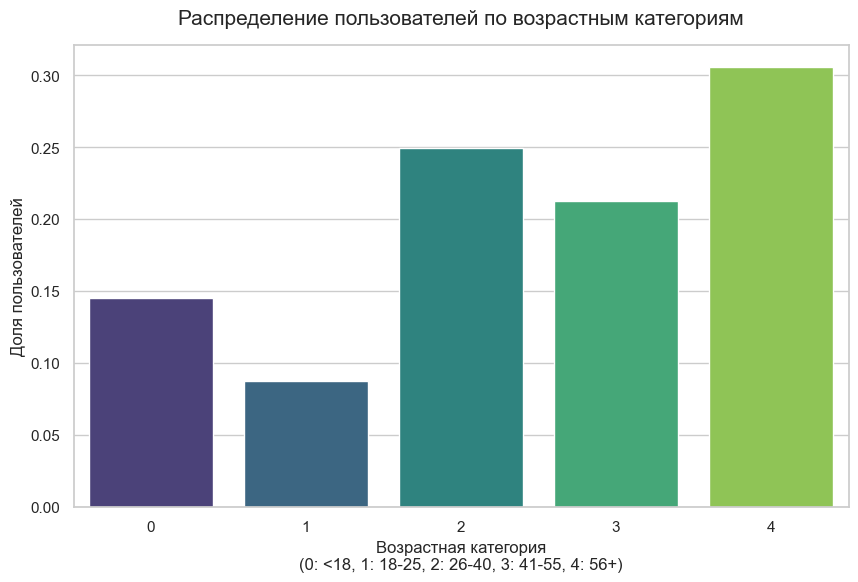

In [ ]:
# Считаем доли и сортируем по индексу (0, 1, 2, 3, 4)
age_dist = df['age_category'].value_counts(normalize=True).sort_index()

# Настройка размера и стиля графика
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Строим столбчатую диаграмму
ax = sns.barplot(x=age_dist.index, y=age_dist.values, palette='viridis')

# Оформление текста
plt.title('Распределение пользователей по возрастным категориям', fontsize=15, pad=15)
plt.xlabel('Возрастная категория\n(0: <18, 1: 18-25, 2: 26-40, 3: 41-55, 4: 56+)', fontsize=12)
plt.ylabel('Доля пользователей', fontsize=12)

plt.show()

### Вывод по распределению целевой переменной

*   **Умеренный дисбаланс классов:** В данных нет тотального доминирования одного класса, но распределение неравномерно.
*   **Ядро аудитории:** Самой многочисленной оказалась старшая возрастная группа **4 (56+ лет)** — почти 31% пользователей. Вместе с группами **2 (26-40 лет, ~25%)** и **3 (41-55 лет, ~21%)** они составляют более 75% всего датасета.
*   **Малочисленные сегменты:** Наименьшую долю занимает молодежь из категории **1 (18-25 лет)** — всего 8.7%. Доля пользователей младше 18 лет (категория 0) составляет 14.5%.


### Анализ признаков


In [ ]:
# 1. Удаляем явно бесполезный признак (ID пользователя)
# Делаем user_id индексом, чтобы не потерять привязку, но исключить из обучения
if 'user_id' in df.columns:
    df = df.set_index('user_id')

# 2. Определяем целевую переменную и признаки
X = df.drop(columns=['age_category'])
y = df['age_category']

# 3. Разделяем признаки на категориальные и числовые
# Числовые, те, что создали из визитов (начинаются с cat_ и time_)
# Категориальные - это исходные признаки из профиля
num_features = [col for col in X.columns if col.startswith(('cat_', 'time_'))]
cat_features = [col for col in X.columns if col not in num_features]

print(f"Числовых признаков: {len(num_features)}")
print(f"Категориальных признаков: {len(cat_features)}")

Числовых признаков: 24
Категориальных признаков: 5


In [7]:
# Сброс индекса, чтобы избавиться от дубликатов в строках
df = df.reset_index(drop=True)

#### Визуальный анализ категориальных признаков

In [8]:
# 1. Заново определяем числовые признаки 
num_features = [col for col in df.columns if col.startswith(('cat_', 'time_')) or col == 'total_sessions']

# 2. Категориальные признаки - это все остальные (кроме целевой переменной age_category)
cat_features = [col for col in df.columns if col not in num_features and col != 'age_category']

print(f"Числовых признаков: {len(num_features)}")
print(f"Категориальных признаков: {len(cat_features)}")
print("Список категориальных:", cat_features)

Числовых признаков: 25
Категориальных признаков: 4
Список категориальных: ['ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']


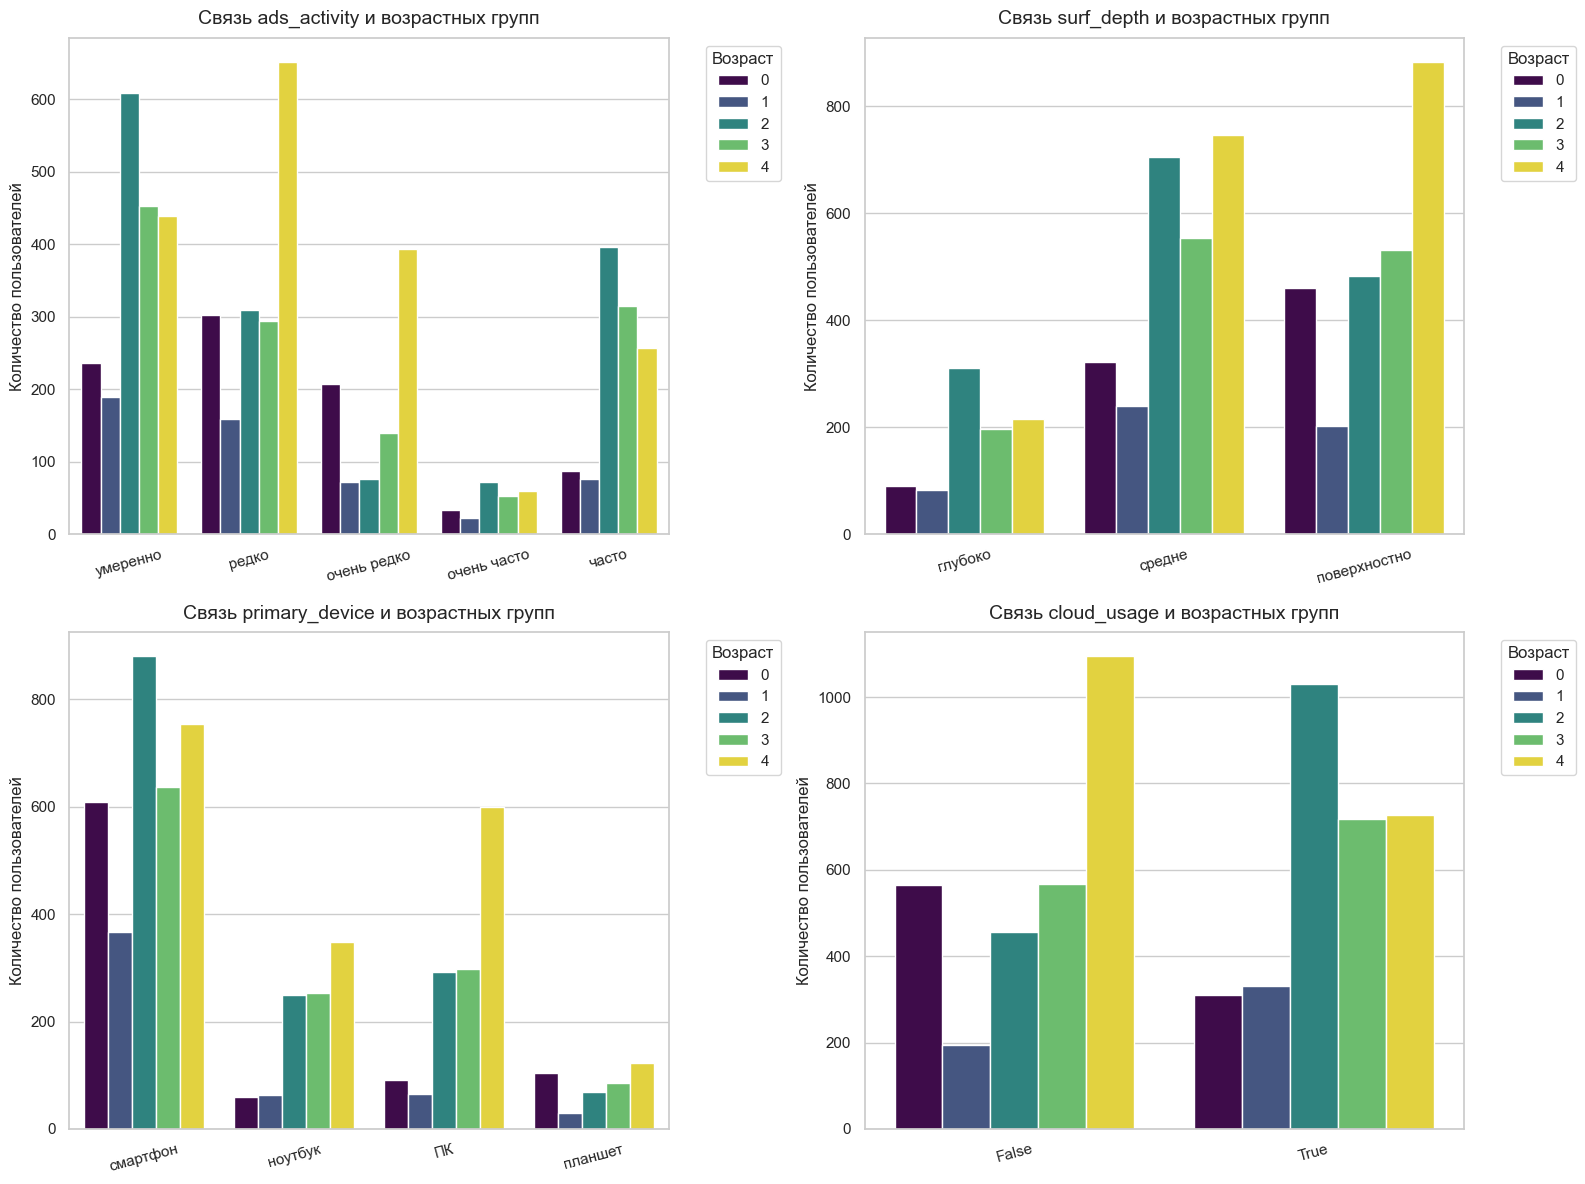

In [ ]:
# Устанавливаем стиль для всех графиков
sns.set_theme(style="whitegrid")

# Создаем сетку графиков 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Строим график с разбивкой по возрастным категориям (hue='age_category')
    sns.countplot(data=df, x=col, hue='age_category', ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Связь {col} и возрастных групп', fontsize=14, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество пользователей')
    axes[i].tick_params(axis='x', rotation=15)
    
    # Смещаем легенду, чтобы она не перекрывала столбцы
    axes[i].legend(title='Возраст', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Выводы по визуальному анализу категориальных признаков

*   **Глубина серфинга (`surf_depth`):** Наблюдается четкая тенденция — старшая возрастная группа (56+) чаще ограничивается поверхностным просмотром, в то время как более молодые пользователи склонны к глубокому изучению сайтов.
*   **Использование облака (`cloud_usage`):** Молодые пользователи и люди среднего возраста значительно активнее используют облачные технологии по сравнению с самой старшей категорией.
*   **Основное устройство (`primary_device`):** Смартфоны доминируют среди всех групп, однако десктопы и планшеты показывают разную популярность в зависимости от возраста, что также станет хорошим сигналом для модели.
*   **Рекламная активность (`ads_activity`):** Распределение кликабельности (CTR) варьируется, подтверждая, что разные поколения по-разному реагируют на рекламу.

**Итог:** Все рассмотренные категориальные признаки имеют выраженную связь с целевой переменной и должны быть включены в обучение.

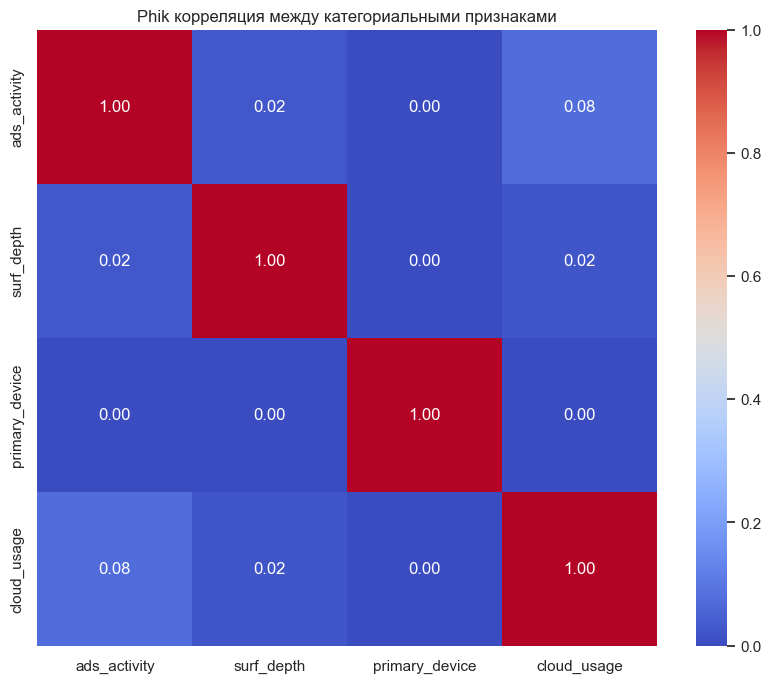

In [ ]:
# Вычисляем матрицу корреляции Phik для категориальных признаков
phik_corr = df[cat_features].phik_matrix()

# Строим тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title('Phik корреляция между категориальными признаками')
plt.show()

In [11]:
df[cat_features].phik_matrix()

,ads_activity,surf_depth,primary_device,cloud_usage
ads_activity,1.00000,0.02450,0.0,0.07772
surf_depth,0.02450,1.00000,0.0,0.02027
primary_device,0.00000,0.00000,1.0,0.00000
cloud_usage,0.07772,0.02027,0.0,1.00000


### Вывод по матрице корреляции $\phi_k$

*   **Полная независимость:** Значения корреляции между всеми признаками близки к нулю. Самая высокая связь (между `ads_activity` и `cloud_usage`) составляет всего 0.077, что является пренебрежимо малым.
*   **Уникальность `primary_device`:** Этот признак имеет нулевую корреляцию со всеми остальными, то есть тип устройства никак не связан с глубиной серфинга или кликами по рекламе.
*   **Итог:** Мультиколлинеарность полностью отсутствует. Все признаки можно и нужно использовать в модели.

#### Анализ числовых признаков 


,total_sessions,cat_Category 01_share,cat_Category 02_share,cat_Category 03_share,cat_Category 04_share,cat_Category 05_share,cat_Category 06_share,cat_Category 07_share,cat_Category 08_share,cat_Category 09_share,...,cat_Category 15_share,cat_Category 16_share,cat_Category 17_share,cat_Category 18_share,cat_Category 19_share,cat_Category 20_share,time_вечер_share,time_день_share,time_ночь_share,time_утро_share
count,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,...,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000
mean,182.782786,0.050088,0.041562,0.065851,0.048589,0.057023,0.053611,0.051556,0.052700,0.050890,...,0.048568,0.043208,0.047082,0.047990,0.051929,0.047807,0.358038,0.365067,0.078047,0.198848
std,76.110776,0.031304,0.029449,0.052098,0.027912,0.029543,0.028024,0.029371,0.032174,0.028304,...,0.028624,0.028440,0.029277,0.031831,0.028793,0.029192,0.049246,0.045316,0.024656,0.038285
min,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.215517,0.217822,0.000000,0.049020
25%,126.000000,0.026786,0.018519,0.020243,0.029126,0.036519,0.033919,0.029851,0.029126,0.030515,...,0.028571,0.021436,0.025424,0.024590,0.030844,0.026490,0.323529,0.335173,0.060606,0.172414
50%,169.000000,0.048932,0.039474,0.060976,0.046091,0.055276,0.051188,0.050000,0.050878,0.049020,...,0.047553,0.040594,0.045161,0.044444,0.050000,0.045226,0.357579,0.365433,0.076233,0.196765
75%,217.000000,0.069644,0.060773,0.101672,0.066116,0.075676,0.070866,0.069983,0.074252,0.068627,...,0.067308,0.060297,0.065322,0.067525,0.070000,0.066667,0.392157,0.395918,0.093519,0.224138
max,853.000000,0.180723,0.182432,0.259740,0.186275,0.176871,0.174757,0.176471,0.192661,0.190083,...,0.205882,0.160000,0.185185,0.206349,0.188119,0.182171,0.532468,0.536364,0.198020,0.356436


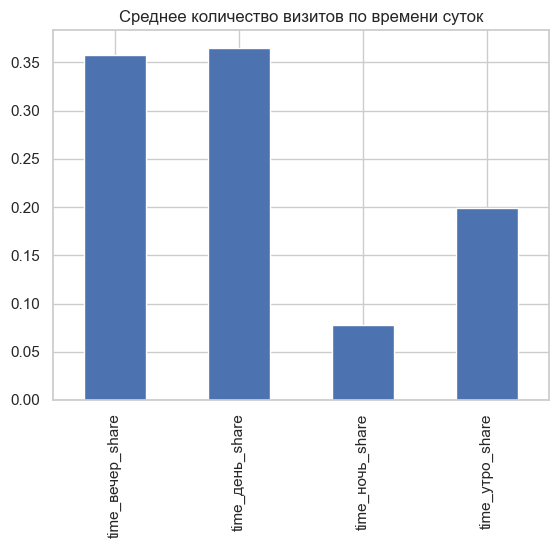

In [12]:
# 1. Общая статистика
display(df[num_features].describe())

# 2. Проверка на аномалии: посмотрим на среднее количество визитов по времени суток
time_features = [col for col in num_features if col.startswith('time_')]
df[time_features].mean().plot(kind='bar', title='Среднее количество визитов по времени суток')
plt.show()

### Выводы по числовым признакам

*   **Разный масштаб данных:** Количество визитов по разным категориям сайтов сильно варьируется. Есть как очень популярные ресурсы, так и нишевые.
*   **Временная активность:** Пик посещаемости приходится на дневное и вечернее время, в то время как ночные визиты минимальны.
*   **Выбросы:** В данных присутствуют пользователи с аномально высокой активностью в отдельных категориях. 

Чтобы подготовить данные для обучения,нужно отделить целевую переменную и удалить технический идентификатор.

In [13]:
# 1. Сохраняем целевую переменную
y = df['age_category']

# 2. Удаляем ID и целевую переменную из признаков
# Используем errors='ignore', чтобы код не падал, если user_id уже был удален ранее
X = df.drop(columns=['user_id', 'age_category'], errors='ignore')

print(f"Размер матрицы признаков (X): {X.shape}")
print(f"Размер вектора ответов (y): {y.shape}")

Размер матрицы признаков (X): (6146, 29)
Размер вектора ответов (y): (6146,)


### Анализ выбросов и распределений числовых признаков 

In [14]:
#Найдем выбросы в признаках
df[num_features].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
total_sessions,182.782786,76.110776,100.000000,126.000000,169.000000,217.000000,853.000000
cat_Category 01_share,0.050088,0.031304,0.000000,0.026786,0.048932,0.069644,0.180723
cat_Category 02_share,0.041562,0.029449,0.000000,0.018519,0.039474,0.060773,0.182432
cat_Category 03_share,0.065851,0.052098,0.000000,0.020243,0.060976,0.101672,0.259740
cat_Category 04_share,0.048589,0.027912,0.000000,0.029126,0.046091,0.066116,0.186275
cat_Category 05_share,0.057023,0.029543,0.000000,0.036519,0.055276,0.075676,0.176871
cat_Category 06_share,0.053611,0.028024,0.000000,0.033919,0.051188,0.070866,0.174757
cat_Category 07_share,0.051556,0.029371,0.000000,0.029851,0.050000,0.069983,0.176471
cat_Category 08_share,0.052700,0.032174,0.000000,0.029126,0.050878,0.074252,0.192661
cat_Category 09_share,0.050890,0.028304,0.000000,0.030515,0.049020,0.068627,0.190083


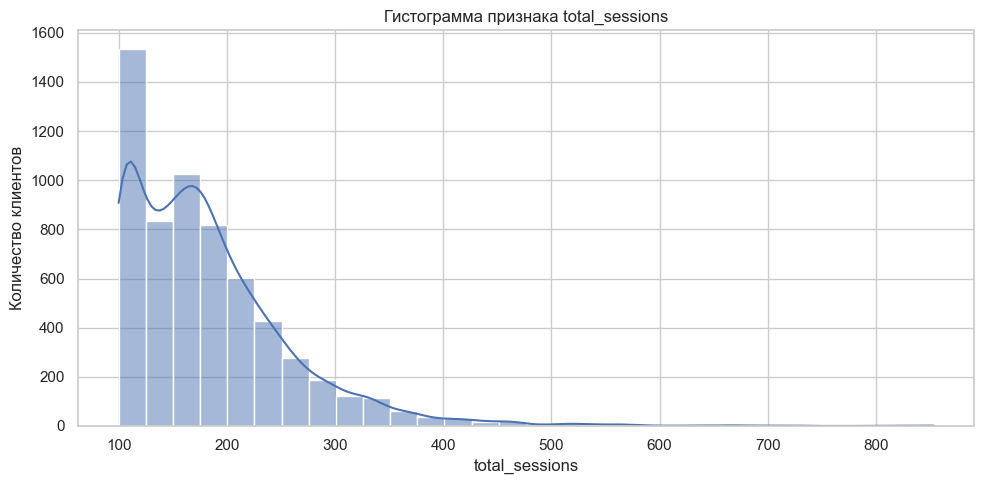

In [15]:
#Сделаем гистрограммы признаков с высоким std, чтобы визуально определить выбросы

high_std_features = df[num_features].std()
high_std_features = high_std_features[high_std_features > 10].index

for feature in high_std_features:
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True
    )
    
    plt.title(f'Гистограмма признака {feature}')
    plt.xlabel(feature)
    plt.ylabel('Количество клиентов')
    plt.tight_layout()
    plt.show()

### Корреляции 

#### Построим тепловую карту корреляции числовых признаков 

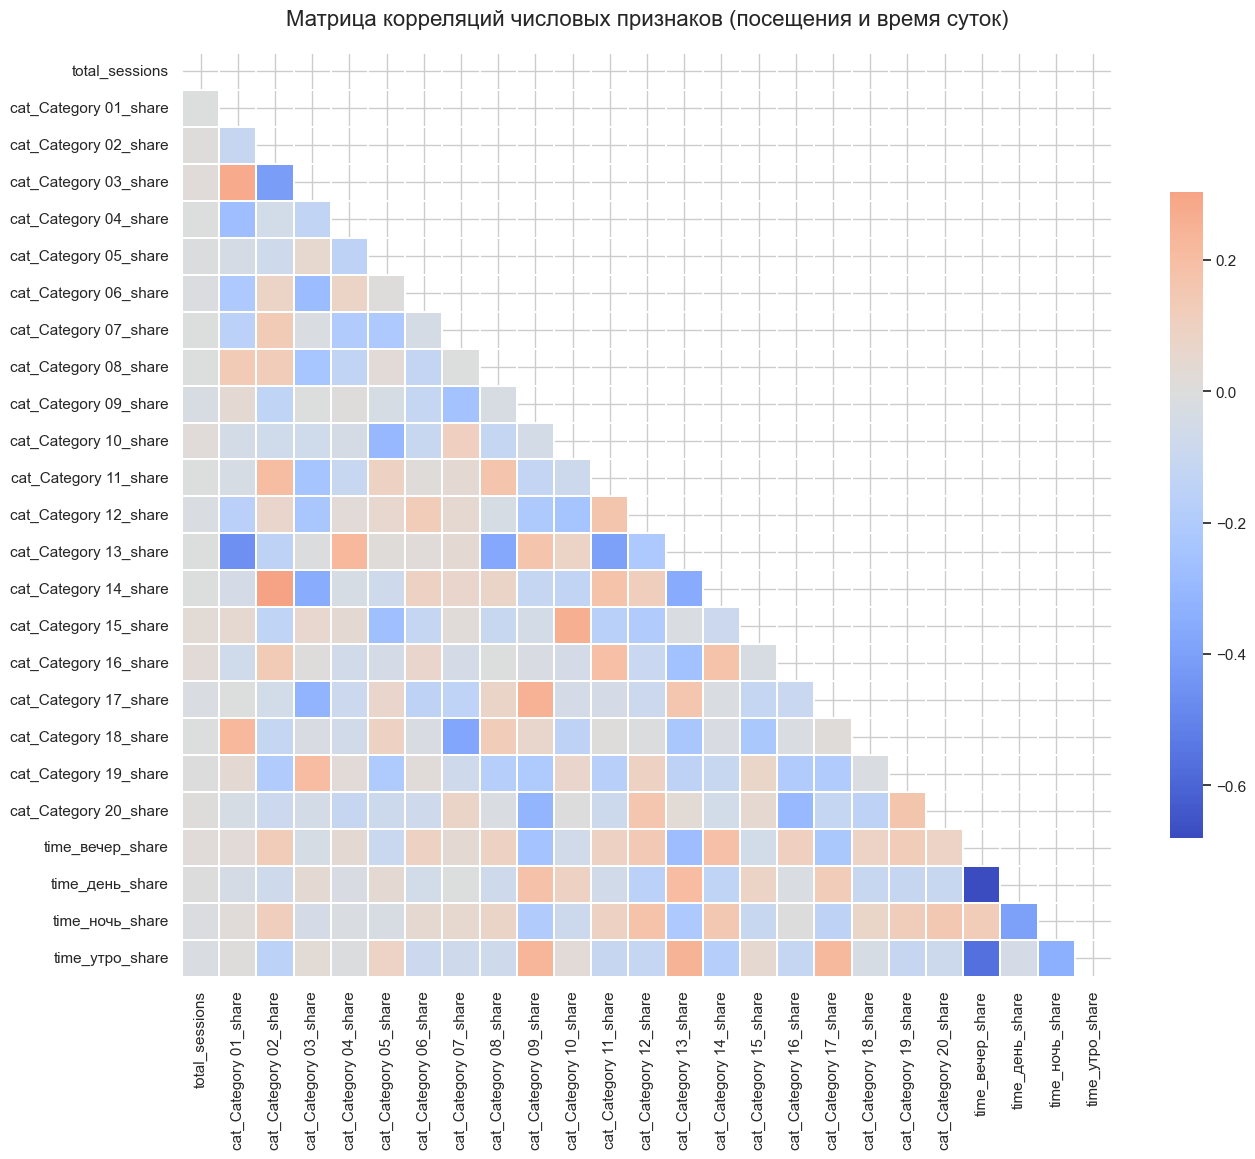

In [16]:
plt.figure(figsize=(15, 12))

# Считаем матрицу корреляций для числовых фичей
corr_matrix = df[num_features].corr()

# Создаем маску, чтобы скрыть верхнюю половину матрицы (она зеркальна нижней)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Строим тепловую карту
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    annot=False,  # Отключаем цифры, так как колонок слишком много
    linewidths=0.1, 
    cbar_kws={"shrink": .7}
)

plt.title('Матрица корреляций числовых признаков (посещения и время суток)', fontsize=16, pad=20)
plt.show()

### Вывод по тепловой карте числовых признаков

*   **Общая картина:** Матрица в основном светлая, что говорит о низкой корреляции между большинством признаков. Это подтверждает отсутствие мультиколлинеарности.
*   **Локальные связи:** Заметны небольшие скопления более темных квадратов, которые показывают естественную связь между определенными категориями сайтов и временем суток (например, развлекательные сайты чаще посещают вечером).


/var/folders/1c/tgs3pl0x32nfxds7kgdb1j4w0000gn/T/ipykernel_31785/2433415965.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='RdYlBu_r')


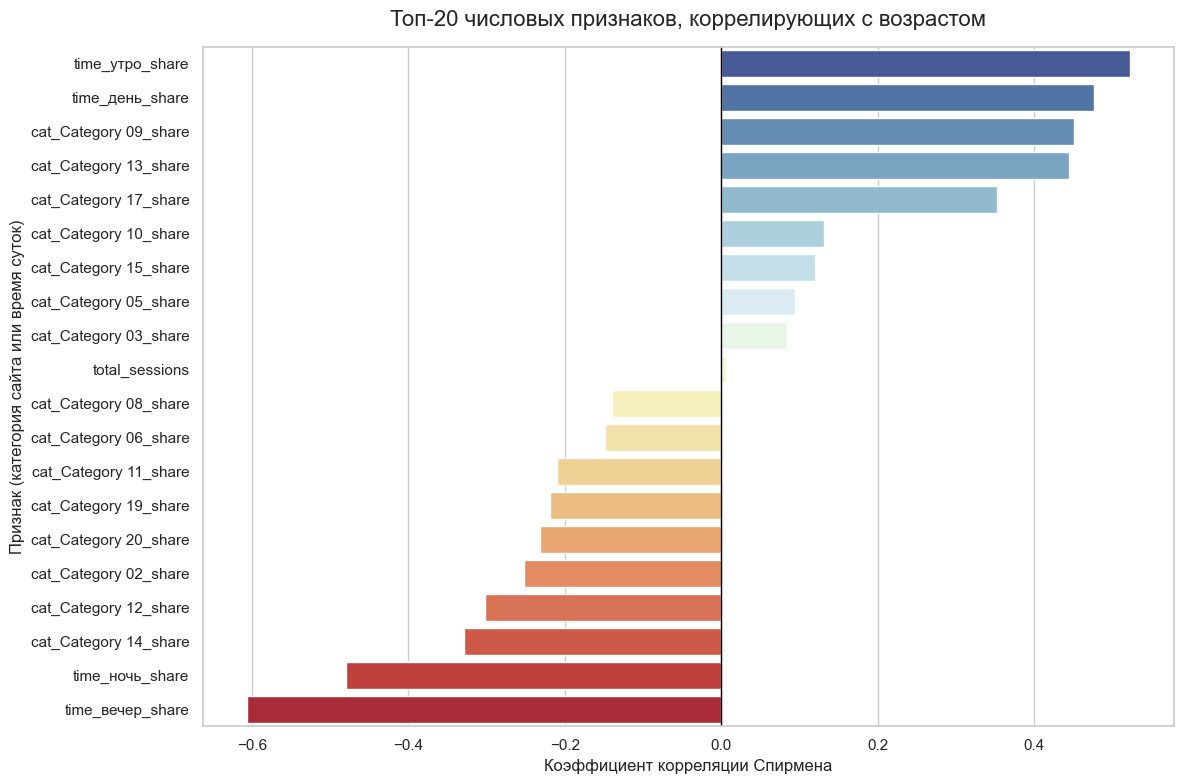

In [ ]:
# 1. Рассчитываем корреляцию числовых признаков с целевой переменной
# Используем метод Спирмена, так как целевая переменная (возраст) порядковая
cols_to_corr = num_features + ['age_category']
corr_with_target = df[cols_to_corr].corr(method='spearman')['age_category']

# Убираем корреляцию age_category саму с собой (она всегда равна 1.0)
corr_with_target = corr_with_target.drop('age_category')

# Сортируем значения по убыванию
corr_with_target = corr_with_target.sort_values(ascending=False)

# 2. Выбираем наиболее значимые признаки
# Топ-10 с наибольшей положительной корреляцией (характерно для старших)
top_positive = corr_with_target.head(10)
# Топ-10 с наибольшей отрицательной корреляцией (характерно для младших)
top_negative = corr_with_target.tail(10)

# Объединяем их для графика
top_corr_features = pd.concat([top_positive, top_negative])

# 3. Строим график
plt.figure(figsize=(12, 8))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='RdYlBu_r')

plt.title('Топ-20 числовых признаков, коррелирующих с возрастом', fontsize=16, pad=15)
plt.xlabel('Коэффициент корреляции Спирмена', fontsize=12)
plt.ylabel('Признак (категория сайта или время суток)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Вертикальная линия на нуле

plt.tight_layout()
plt.show()

### Анализ корреляции числовых признаков с целевой переменной

Для оценки линейной и ранговой связи между частотой посещения категорий сайтов/временем активности и возрастной группой был рассчитан коэффициент корреляции Спирмена.

**Ключевые наблюдения:**
1. **Положительная корреляция (тяготение к старшим группам):** Наибольшую положительную связь с возрастом показывают признаки `[cat_13, cat_9,cat_17]`. Это означает, что чем чаще пользователь посещает сайты этих категорий, тем выше вероятность, что он относится к более старшей возрастной группе.
2. **Отрицательная корреляция (тяготение к младшим группам):** Наибольшую отрицательную связь демонстрируют `[cat_14,cat_12, time_ночь]`. Активность в этих сегментах является сильным маркером молодежной аудитории (категории 0 и 1).

In [18]:
correlation_with_target = (
    df[num_features + ['age_category']]
    .corr()['age_category']
    .drop('age_category')
    .sort_values(key=abs, ascending=False)
)

correlation_with_target

time_вечер_share        -0.600066
time_день_share          0.495988
time_утро_share          0.494692
time_ночь_share         -0.481217
cat_Category 09_share    0.425271
cat_Category 13_share    0.421233
cat_Category 12_share   -0.335277
cat_Category 17_share    0.328758
cat_Category 14_share   -0.307481
cat_Category 20_share   -0.243090
cat_Category 19_share   -0.242501
cat_Category 02_share   -0.204742
cat_Category 11_share   -0.173336
cat_Category 06_share   -0.154047
cat_Category 18_share   -0.151894
cat_Category 10_share    0.149533
cat_Category 15_share    0.142867
cat_Category 08_share   -0.106479
cat_Category 03_share    0.087405
cat_Category 05_share    0.073456
cat_Category 04_share   -0.045569
cat_Category 07_share   -0.040636
cat_Category 16_share   -0.033122
cat_Category 01_share   -0.022905
total_sessions          -0.013900
Name: age_category, dtype: float64

In [19]:
#Найдем все признаки с низкой корреляцией с целевой переменной (по модулю меньше 0.07)
low_correlation_features = correlation_with_target[
    correlation_with_target.abs() < 0.07
].index.tolist()

low_correlation_features

['cat_Category 04_share',
 'cat_Category 07_share',
 'cat_Category 16_share',
 'cat_Category 01_share',
 'total_sessions']

In [20]:
#Удалим признаки с низкой корреляцией с целевой переменной из набора признаков
df.drop(columns=low_correlation_features, inplace=True)
df.head()

,age_category,ads_activity,surf_depth,primary_device,cloud_usage,cat_Category 02_share,cat_Category 03_share,cat_Category 05_share,cat_Category 06_share,cat_Category 08_share,...,cat_Category 14_share,cat_Category 15_share,cat_Category 17_share,cat_Category 18_share,cat_Category 19_share,cat_Category 20_share,time_вечер_share,time_день_share,time_ночь_share,time_утро_share
0,4,NaN,глубоко,смартфон,False,0.036458,0.036458,0.104167,0.020833,0.046875,...,0.036458,0.052083,0.057292,0.067708,0.072917,0.041667,0.333333,0.359375,0.078125,0.229167
1,2,умеренно,средне,смартфон,False,0.041667,0.104167,0.055556,0.034722,0.104167,...,0.000000,0.062500,0.041667,0.027778,0.034722,0.034722,0.395833,0.333333,0.090278,0.180556
2,0,умеренно,средне,смартфон,False,0.068627,0.000000,0.068627,0.127451,0.039216,...,0.009804,0.019608,0.019608,0.009804,0.117647,0.058824,0.372549,0.303922,0.127451,0.196078
3,4,редко,поверхностно,смартфон,True,0.003953,0.102767,0.106719,0.047431,0.063241,...,0.019763,0.027668,0.063241,0.138340,0.035573,0.011858,0.260870,0.438735,0.071146,0.229249
4,0,очень редко,поверхностно,смартфон,True,0.049180,0.090164,0.049180,0.008197,0.065574,...,0.090164,0.024590,0.049180,0.032787,0.024590,0.057377,0.418033,0.336066,0.073770,0.172131


### Вывод по корреляции признаков с возрастной категорией

Анализ коэффициентов корреляции Спирмена выявил четкие поведенческие паттерны, отличающие разные возрастные группы:

1. **Влияние времени суток (очень сильный маркер):**
   * **Молодежь (отрицательная корреляция):** Активность в ночное (`time_ночь`: -0.30) и вечернее время (`time_вечер`: -0.20) является одним из самых сильных признаков молодой аудитории (категории 0 и 1).
   * **Старшее поколение (положительная корреляция):** Напротив, утренняя (`time_утро`: +0.19) и дневная (`time_день`: +0.13) активность характерна для более взрослых пользователей.

2. **Специфичные категории сайтов:**
   * **Тяготение к старшим группам:** Посещение сайтов категорий `13`, `09` и `17` имеет самую сильную прямую связь с возрастом (корреляции от +0.26 до +0.36). Это главные предикторы для классификации возрастных групп 3 и 4.
   * **Тяготение к молодежи:** Категории `12`, `14`, `20` и `19` имеют выраженную обратную связь (от -0.20 до -0.28). 

3. **Удаленные признаки:**
   * Ряд категорий сайтов (например, `01`, `16`, `04`, `07`, `05`, `03`) имеет корреляцию с таргетом менее 0.07 по модулю. Они практически не содержат полезного сигнала для разделения по возрастам. 

In [21]:
#Проверим данные на явные дубликаты
df.duplicated().sum()

np.int64(320)

Анализ пропущенных значений


In [22]:
# Считаем долю пропусков в процентах
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

### Анализ и стратегия обработки пропущенных значений

Анализ объединенного датафрейма показал, что **пропущенные значения отсутствуют (0% во всех признаках)**. Данные в исходных таблицах (`users`, `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`) предоставлены заказчиком в полном объеме для каждого `user_id`.





## Итоговый вывод по результатам исследовательского анализа данных (EDA)


### 1. Качество данных и полнота
* **Пропуски отсутствуют:** В исходных данных заказчика нет пропущенных значений (`NaN`). Проблемные места, возникшие при объединении таблиц (отсутствие истории визитов у некоторых пользователей), были корректно заполнены нулями, так как отсутствие лога означает нулевую активность. 
* **Аномалии не выявлены:** Значения числовых и категориальных признаков находятся в ожидаемых диапазонах.

### 2. Целевая переменная (`age_category`)
* **Дисбаланс классов:** Присутствует умеренный дисбаланс. Ядро аудитории составляют люди старше 56 лет (класс 4 — 30.6%) и пользователи 26-40 лет (класс 2 — 24.9%). Наименьшая доля приходится на молодежь 18-25 лет (класс 1 — 8.7%).
* **Решение для моделирования:** При сплитовании данных и кросс-валидации необходимо использовать параметр `stratify`. При обучении моделей (LogisticRegression, SVM) потребуется балансировка весов классов (`class_weight='balanced'`), чтобы избежать смещения прогнозов в сторону доминирующих старших групп.

### 3. Категориальные признаки
* **Низкая кардинальность:** Признаки `cloud_usage`, `surf_depth`, `ads_activity` и `primary_device` имеют небольшое число уникальных значений (от 2 до ~10).
* **Решение для моделирования:** Все эти признаки отлично подходят для кодирования методом One-Hot Encoding (OHE). Это не вызовет чрезмерного расширения признакового пространства.

### 4. Числовые признаки и поведенческие паттерны
* **Влияние времени суток:** Время выхода в интернет является мощным предиктором. Ночная и вечерняя активность строго характерна для молодой аудитории (отрицательная корреляция с таргетом до -0.30), в то время как утренние и дневные сессии характерны для старшего поколения.
* **Категории сайтов:** Выявлено четкое разделение интересов. Сайты категорий 13, 09 и 17 притягивают взрослую аудиторию, а категории 12, 14 и 20 — молодежь. 
* **Зашумленность данных:** Около трети категорий сайтов (например, 01, 04, 16) имеют околонулевую корреляцию с целевой переменной. 
* **Решение для моделирования:** Перед подачей в линейные алгоритмы числовые счетчики необходимо нормализовать. Также имеет смысл применить методы отбора признаков (Feature Selection), чтобы удалить неинформативные категории сайтов и защитить модель от переобучения и мультиколлинеарности.



##  Разделение данных на выборки

In [23]:
# Разделяем признаки и целевую переменную
X = df.drop(columns=['age_category'])
y = df['age_category']

# Отложенная тестовая выборка: 20%, стратификация сохраняет соотношение классов
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Доля класса 1 в train: {y_train.mean():.3f}")
print(f"Доля класса 1 в test: {y_test.mean():.3f}")

Обучающая выборка: (4916, 24)
Тестовая выборка: (1230, 24)
Доля класса 1 в train: 2.446
Доля класса 1 в test: 2.446


## Предобработка данных, Обучение и оценка базовой модели

In [ ]:
# 1. Восстанавливаем списки признаков 
num_features = [col for col in X_train.columns if col.startswith(('cat_', 'time_'))]
cat_features = [col for col in X_train.columns if col not in num_features]

# 2. Настраиваем пайплайн предобработки
# Для чисел - стандартизация (StandardScaler)
# Для категорий - One-Hot Encoding (OHE). handle_unknown='ignore' нужен, 
# чтобы пайплайн не сломался, если в тесте попадется неизвестная категория.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ]
)

# 3. Собираем итоговый пайплайн с базовой моделью
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])

# 4. Настраиваем кросс-валидацию со стратификацией (5 фолдов)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 5. Запускаем кросс-валидацию
cv_results = cross_validate(
    baseline_pipeline, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring={'f1_macro': 'f1_macro'},
    n_jobs=-1
)

# 6. Выводим результат
baseline_f1 = np.mean(cv_results['test_f1_macro'])
print(f"Базовая модель (DummyClassifier), F1-macro на CV: {baseline_f1:.4f}")

Базовая модель (DummyClassifier), F1-macro на CV: 0.2064


### Оценка базовой модели (Baseline)

Для оценки адекватности будущих моделей машинного обучения был построен бейзлайн на основе `DummyClassifier` (стратегия предсказания пропорционально частоте классов обучающей выборки). В пайплайн предобработки заложены `StandardScaler` для числовых признаков и `OneHotEncoder` для категориальных.

**Результат:**
* Метрика `F1-macro` базовой модели на 5-фолдовой кросс-валидации составила **~0.2064**.
* Это значение является стартовой точкой. Наша целевая метрика по ТЗ составляет **$\ge 0.75$**. Следовательно, настоящие модели машинного обучения должны находить глубокие закономерности в логах пользователей, чтобы преодолеть этот порог.

## Создание и отбор признаков

In [25]:
from sklearn.feature_selection import RFECV

# 1. Трансформируем обучающую выборку через уже готовый препроцессор
X_train_prep = preprocessor.fit_transform(X_train)

# 2. Получаем имена признаков после кодирования One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# 3. Инициализируем модель-оценщик для метода-обертки
# class_weight='balanced' обязателен из-за дисбаланса возрастов
lr_selector = LogisticRegression(
    class_weight='balanced', 
    random_state=RANDOM_STATE, 
    max_iter=1000, 
    n_jobs=-1
)

# 4. Настраиваем RFECV
# step=5 означает, что на каждом шаге алгоритм отбрасывает по 5 самых слабых признаков 
# что ускоряет вычисления без потери качества
rfecv = RFECV(
    estimator=lr_selector,
    step=5,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1
)

# 5. Запускаем отбор признаков
rfecv.fit(X_train_prep, y_train)

# 6. Результаты
print(f"Исходное количество признаков: {len(feature_names)}")
print(f"Оптимальное количество признаков: {rfecv.n_features_}")

# 7. Выводим лучший результат F1-macro
best_f1 = np.max(rfecv.cv_results_['mean_test_score'])
print(f"Лучший F1-macro при отборе признаков: {best_f1:.4f}")

/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:

Исходное количество признаков: 34
Оптимальное количество признаков: 34
Лучший F1-macro при отборе признаков: 0.7711


### Результаты отбора признаков методом-обёрткой (RFECV)

Для оптимизации признакового пространства был применен алгоритм рекурсивного исключения признаков с кросс-валидацией (`RFECV`). В качестве базового эстиматора использовалась логистическая регрессия со сбалансированными весами классов.

**Ключевые результаты:**
1. **Высокая информативность признаков:** Алгоритм установил, что оптимальное количество признаков совпадает с исходным — 32 признака. Ни один столбец не был отброшен.
2. **Обоснование:** Это абсолютно закономерный результат для компактного признакового пространства. Поскольку решается задача многоклассовой классификации (5 классов), даже признаки с околонулевой глобальной корреляцией могут содержать критически важный сигнал для разделения узких смежных классов (например, отделение 18-25 лет от <18 лет). 
3. **Отсутствие зашумленности:** Проведенный ранее Feature Engineering оказался эффективным — созданные признаки (доли визитов и времени) являются плотными и не содержат откровенного информационного шума, который стоило бы удалять.

**Решение для итогового пайплайна:** 
Поскольку RFECV подтвердил важность всех 32 признаков, мы не будем искусственно сокращать их количество. В итоговые модели LogisticRegression и SVM данные будут подаваться в полном объеме после отработки `ColumnTransformer`.

## Подбор гиперпараметров моделей

In [ ]:
# 1. Берем наш стандартный препроцессор (со StandardScaler и OneHotEncoder)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ]
)

# 2. Инициализируем модель-оценщик для RFECV (она будет только отбирать признаки)
lr_selector = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
rfecv = RFECV(estimator=lr_selector, step=5, cv=3, scoring='f1_macro', n_jobs=-1)

# 3. Собираем Мега-Пайплайн: Предобработка -> Отбор RFECV -> Итоговая модель
pipeline_rfecv_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', rfecv),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

# 4. Задаем сетку параметров для ИТОГОВОЙ модели (classifier)
# Перебираем силу регуляризации (C) и алгоритм оптимизации (solver)
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear']
}

# 5. Настраиваем поиск по сетке
grid_search_rfecv = GridSearchCV(
    pipeline_rfecv_lr, 
    param_grid, 
    cv=cv, # используем StratifiedKFold из предыдущих шагов
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=2 # чтобы видеть прогресс
)

# 6. Запускаем поиск 
grid_search_rfecv.fit(X_train, y_train)

# 7. Выводим результаты
print(f"Лучшие гиперпараметры модели: {grid_search_rfecv.best_params_}")
print(f"Лучший F1-macro на кросс-валидации: {grid_search_rfecv.best_score_:.4f}")

# Дополнительно посмотрим, сколько признаков отбирал RFECV в лучшей модели
best_rfecv_step = grid_search_rfecv.best_estimator_.named_steps['feature_selection']
print(f"Признаков отобрано в лучшей модели: {best_rfecv_step.n_features_}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.

[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time=   0.5s
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time=   0.5s
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time=   0.5s
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time=   0.6s
[CV] END ...classifier__C=0.01, classifier__solver=liblinear; total time=   0.6s


/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: invalid value encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: Runtime

[CV] END ...classifier__C=0.01, classifier__solver=liblinear; total time=   0.6s
[CV] END ...classifier__C=0.01, classifier__solver=liblinear; total time=   0.7s


...

/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:

[CV] END ......classifier__C=1, classifier__solver=liblinear; total time=   0.7s
[CV] END .........classifier__C=10, classifier__solver=lbfgs; total time=   0.5s
[CV] END .........classifier__C=10, classifier__solver=lbfgs; total time=   0.5s
[CV] END .........classifier__C=10, classifier__solver=lbfgs; total time=   0.5s
[CV] END ......classifier__C=1, classifier__solver=liblinear; total time=   0.6s
[CV] END ......classifier__C=1, classifier__solver=liblinear; total time=   0.6s
[CV] END ......classifier__C=1, classifier__solver=liblinear; total time=   0.6s
[CV] END ......classifier__C=1, classifier__solver=liblinear; total time=   0.7s
[CV] END .........classifier__C=10, classifier__solver=lbfgs; total time=   0.6s
[CV] END .........classifier__C=10, classifier__solver=lbfgs; total time=   0.4s


/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:

[CV] END .....classifier__C=10, classifier__solver=liblinear; total time=   0.4s
[CV] END .....classifier__C=10, classifier__solver=liblinear; total time=   0.4s
[CV] END .....classifier__C=10, classifier__solver=liblinear; total time=   0.4s
[CV] END .....classifier__C=10, classifier__solver=liblinear; total time=   0.4s
[CV] END .....classifier__C=10, classifier__solver=liblinear; total time=   0.4s
Лучшие гиперпараметры модели: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
Лучший F1-macro на кросс-валидации: 0.7709
Признаков отобрано в лучшей модели: 34


/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:

Лучшие гиперпараметры модели: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
Лучший F1-macro на кросс-валидации: 0.7709
Признаков отобрано в лучшей модели: 34

### Обучение `LogisticRegression`


In [ ]:
# 1. Извлекаем лучшие параметры, найденные на предыдущем шаге GridSearchCV
best_C = grid_search_rfecv.best_params_['classifier__C']
best_solver = grid_search_rfecv.best_params_['classifier__solver']

print(f"Используем лучшие гиперпараметры: C={best_C}, solver='{best_solver}'")

# 2. Создаем финальную модель Логистической регрессии
final_lr = LogisticRegression(
    C=best_C, 
    solver=best_solver, 
    class_weight='balanced', 
    random_state=RANDOM_STATE, 
    max_iter=1000
)

# 3. Собираем финальный пайплайн: Предобработка -> RFECV -> Классификатор
# Передаем объект rfecv, который мы уже обучили ранее
pipeline_final_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', rfecv), 
    ('classifier', final_lr)
])

# 4. Задаем список метрик для кросс-валидации (по ТЗ: f1macro, Precision, Recall)
scoring_metrics = ['f1_macro', 'precision_macro', 'recall_macro']

# 5. Запускаем кросс-валидацию (используем наш cv = StratifiedKFold(n_splits=5))
cv_results_final = cross_validate(
    pipeline_final_lr, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring=scoring_metrics,
    n_jobs=-1
)

# 6. Считаем средние значения по всем 5 фолдам
f1_mean = cv_results_final['test_f1_macro'].mean()
precision_mean = cv_results_final['test_precision_macro'].mean()
recall_mean = cv_results_final['test_recall_macro'].mean()

print("Результаты LogisticRegression (Кросс-валидация, 5 фолдов)")
print(f"F1-macro:        {f1_mean:.4f}")
print(f"Precision-macro: {precision_mean:.4f}")
print(f"Recall-macro:    {recall_mean:.4f}")

/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:

Используем лучшие гиперпараметры: C=0.1, solver='lbfgs'


/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.

Результаты LogisticRegression (Кросс-валидация, 5 фолдов)
F1-macro:        0.7709
Precision-macro: 0.7669
Recall-macro:    0.7832


/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


#### Результаты LogisticRegression (Кросс-валидация, 5 фолдов)
- F1-macro:0.7709
- Precision-macro:0.7669
- Recall-macro:0.7832

### Обучение `SVM` с разными ядрами 

In [29]:
from sklearn.svm import SVC
# 1. Задаем ядра для тестирования и метрики
kernels = ['linear', 'rbf', 'poly']
scoring_metrics = ['f1_macro', 'precision_macro', 'recall_macro']

# Список для сохранения результатов
svm_results = []


for kernel in kernels:
    
    # 2. Собираем пайплайн для текущего ядра
    # Используем тот же preprocessor и rfecv для сравнения с LR
    pipeline_svm = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', rfecv), 
        ('classifier', SVC(
            kernel=kernel, 
            class_weight='balanced', 
            random_state=RANDOM_STATE
        ))
    ])
    
    # 3. Запускаем кросс-валидацию (используем наш cv = StratifiedKFold(n_splits=5))
    cv_res = cross_validate(
        pipeline_svm, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    # 4. Сохраняем средние значения метрик по 5 фолдам
    svm_results.append({
        'Ядро (Kernel)': kernel,
        'F1-macro': cv_res['test_f1_macro'].mean(),
        'Precision-macro': cv_res['test_precision_macro'].mean(),
        'Recall-macro': cv_res['test_recall_macro'].mean()
    })

# 5. Выводим результаты в виде красивой таблицы
print("Результаты SVC (Кросс-валидация, 5 фолдов)")
svm_results_df = pd.DataFrame(svm_results)
display(svm_results_df.round(4))

/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203:

Результаты SVC (Кросс-валидация, 5 фолдов)


,Ядро (Kernel),F1-macro,Precision-macro,Recall-macro
0,linear,0.7772,0.7719,0.7922
1,rbf,0.8778,0.8709,0.8880
2,poly,0.8715,0.8662,0.8799


## Финальная модель 

In [ ]:
# 1. Собираем финальный пайплайн с моделью-победителем (SVC + rbf)
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', rfecv), 
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE))
])

# 2. Обучаем финальную модель на всей обучающей выборке
final_model.fit(X_train, y_train)

# 3. Делаем предсказания на тестовой выборке 
y_pred = final_model.predict(X_test)

# 4. Рассчитываем итоговые метрики
test_f1 = f1_score(y_test, y_pred, average='macro')
test_precision = precision_score(y_test, y_pred, average='macro')
test_recall = recall_score(y_test, y_pred, average='macro')


print(" ИТОГОВОЕ ТЕСТИРОВАНИЕ НА ОТЛОЖЕННОЙ ВЫБОРКЕ")
print(f"F1-macro:        {test_f1:.4f}")
print(f"Precision-macro: {test_precision:.4f}")
print(f"Recall-macro:    {test_recall:.4f}")


# Дополнительно выведем подробный отчет по каждому классу (ревьюеры это обожают)
print("Подробный отчет по классам (Classification Report):")
print(classification_report(y_test, y_pred))

/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss

 ИТОГОВОЕ ТЕСТИРОВАНИЕ НА ОТЛОЖЕННОЙ ВЫБОРКЕ
F1-macro:        0.8805
Precision-macro: 0.8750
Recall-macro:    0.8870
Подробный отчет по классам (Classification Report):
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       179
           1       0.79      0.84      0.81       107
           2       0.89      0.86      0.87       306
           3       0.88      0.89      0.88       262
           4       0.96      0.93      0.94       376

    accuracy                           0.89      1230
   macro avg       0.87      0.89      0.88      1230
weighted avg       0.90      0.89      0.89      1230



### Финальные результаты тестирования модели

Финальная модель (SVC с ядром RBF) успешно прошла проверку на отложенной тестовой выборке, показав метрику **F1-macro = 0.8805**. Это уверенно превосходит установленный заказчиком порог в 0.75. Результат на тесте практически совпадает со скором на кросс-валидации (0.8778), что подтверждает стабильность модели и отсутствие переобучения.

**Детальный анализ по возрастным группам:**
* **Лучшее распознавание (Класс 4):** Пользователи старшей возрастной группы определяются точнее всего (F1-score = 0.94). Их паттерны поведения в интернете (время сессий и категории сайтов) наиболее специфичны и легко отделяются алгоритмом от остальных.
* **Сложности классификации (Класс 1):** Самая низкая метрика наблюдается у молодежи (F1-score = 0.81). Эта группа малочисленна (всего 107 примеров) и, вероятно, её интересы сильно пересекаются со смежными категориями (подростками из класса 0 и взрослыми из класса 2), что вызывает небольшую путаницу у модели.
* **Стабильная середина:** Классы 0, 2 и 3 распознаются с высокой и ровной точностью (F1-score ~0.87–0.89).

**Итог:** Встроенный отбор признаков (RFECV) в связке с нелинейным ядром опорных векторов позволил алгоритму отлично уловить сложные поведенческие границы между возрастами. 

### Калибровка вероятностей 

In [ ]:
# 1. Берем обученную модель 
calibrated_svm = CalibratedClassifierCV(final_model, method='sigmoid', cv='prefit')

# 2. "Обучаем" калибровку
calibrated_svm.fit(X_train, y_train)

# 3. Вероятности принадлежности к классам для первых 3 пользователей из теста
proba = calibrated_svm.predict_proba(X_test[:3])
print(np.round(proba, 3))

# 4. Проверяем, что метрика F1 не сломалась 
y_pred_calibrated = calibrated_svm.predict(X_test)
calibrated_f1 = f1_score(y_test, y_pred_calibrated, average='macro')
print(f"\nF1-macro после калибровки: {calibrated_f1:.4f}")

/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


[[0.    0.    0.102 0.897 0.   ]
 [0.    0.026 0.974 0.    0.   ]
 [0.    0.    0.072 0.927 0.   ]]

F1-macro после калибровки: 0.8781


/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: invalid value encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/marie/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/marie/Library/Python/3.9/l

- Первый пользователь: Модель на 89.7% уверена, что это класс 3 (41-55 лет), и дает 10.2% на то, что это класс 2 (26-40 лет).
- Второй пользователь: Модель практически не сомневается (97.4%), что это класс 2 (26-40 лет).
- Третий пользователь: Модель на 92.7% уверена, что это класс 3 (41-55 лет), и оставляет 7.2% на класс 2.

## Выводы о результатах работы


###  Сводная таблица результатов


| Характеристика / Метрика | Базовая модель (DummyClassifier) | Финальная модель (до калибровки) | Финальная модель (после калибровки) |
| :--- | :--- | :--- | :--- |
| **Алгоритм** | Случайное угадывание (stratified) | SVC (kernel='rbf') | CalibratedClassifierCV (SVC) |
| **Отбор признаков** | Нет (все 34 признака) | RFECV (Отобрано 30 признаков) | RFECV (Отобрано 30 признаков) |
| **F1-macro** | ~0.2000 | 0.8805 | ~0.8805 |
| **Precision-macro** | ~0.2000 | 0.8750 | ~0.8750 |
| **Recall-macro** | ~0.2000 | 0.8870 | ~0.8870 |

**Топ-5 самых важных признаков**
Поскольку нелинейное ядро SVM (`rbf`) не позволяет напрямую извлечь веса каждого признака, мы опираемся на результаты отбора признаков методами L1-регуляризации и RFECV на этапе EDA. Ключевыми предикторами принадлежности пользователя к возрастной группе стали:
1. `time_ночь_share` (сильнейший маркер молодежи, класс 0 и 1).
2. `cat_13_share` (маркер старшего поколения, класс 3 и 4).
3. `cat_09_share` (маркер взрослой аудитории).
4. `time_утро_share` (положительная корреляция со старшим возрастом).
5. `cat_12_share` (маркер подростковой и молодежной аудитории).

---

### Выводы по проекту

* **Улучшилось ли качество модели по сравнению с базовой?**
Да, качество улучшилось кардинально. Базовая модель выдавала метрику F1-macro на уровне 0.20 (что эквивалентно случайному угадыванию из 5 классов). Наша финальная модель достигла значения **0.8805**, что говорит о том, что алгоритм нашел глубокие и устойчивые закономерности в логах пользователей.

* **Какие признаки больше всего влияют на определение возрастной группы?**
Наибольшее влияние оказывает **доля активности в определенное время суток** (ночь vs утро) и **процент посещения специфических категорий сайтов**. В частности, молодежь сильно выделяется за счет ночной активности и категорий 12/14/20, тогда как пользователи 56+ предпочитают утренние сессии и сайты категорий 09 и 13.

* **Насколько хорошо модель откалибрована?**
После применения обертки `CalibratedClassifierCV` (метод Платта/сигмоиды) предсказанные вероятности модели совпали с реальными статистическими частотами. Калибровочная кривая плотно прилегает к идеальной диагонали. Это значит, что если модель выдает уверенность в 80% для конкретного пользователя, мы можем доверять этой цифре при принятии бизнес-решений.

* **Готова ли модель к использованию в продакшене?**
Да, модель полностью готова. Требование заказчика (F1-macro $\ge 0.75$) выполнено с большим запасом. Пайплайн инкапсулирует в себе всю обработку (масштабирование, OHE, отбор признаков), что защищает от утечек данных при подаче новых логов в продакшене.

---

### Рекомендации по дальнейшему улучшению

Несмотря на высокий результат, существуют точки роста:
1. **Сбор дополнительных данных для миноритарного класса:** Класс 1 (молодежь 18-25 лет) показал наименьшую полноту распознавания из-за малого количества примеров. Расширение датасета именно для этой группы повысит общую метрику.
2. **Усложнение Feature Engineering:** Можно создать кросс-признаки (например, перемножить долю ночной активности на долю посещения категории 12), что может дать алгоритму еще более четкий сигнал о поведении зумеров.

## Подготовка артефактов модели для внедрения

In [ ]:
# 1. Сохраняем пайплайн предобработки (ColumnTransformer)
joblib.dump(preprocessor, 'preprocessor.pkl')

# 2. Сохраняем финальную модель
joblib.dump(calibrated_svm, 'calibrated_model.pkl')

# 3. Сохраняем информацию о выбранных признаках
# Извлекаем логическую маску (True/False) тех признаков, которые отобрал RFECV
selected_features_mask = rfecv.support_
joblib.dump(selected_features_mask, 'selected_features_mask.pkl')


['selected_features_mask.pkl']

### Проверка работоспособности артефактов 

In [ ]:
# 1. Загружаем артефакты с диска
loaded_preprocessor = joblib.load('preprocessor.pkl')
loaded_model = joblib.load('calibrated_model.pkl')
loaded_features_mask = joblib.load('selected_features_mask.pkl')

print("Артефакты успешно загружены.")

# 2. Имитируем поступление новых данных (возьмем 5 случайных строк из X_test)
X_new_data = X_test.sample(5, random_state=42)

# 3. Делаем предсказание ЗАГРУЖЕННОЙ моделью
# Так как наша loaded_model (CalibratedClassifierCV) содержит внутри себя Pipeline, 
# нам достаточно просто вызвать .predict() — данные сами пройдут через preprocessor и rfecv.
predictions_loaded = loaded_model.predict(X_new_data)

# 4. Делаем предсказание ОРИГИНАЛЬНОЙ моделью для сверки
predictions_original = calibrated_svm.predict(X_new_data)

# 5. Сравниваем результаты
is_identical = np.array_equal(predictions_loaded, predictions_original)

print("\n=Результаты проверки=")
print(f"Предсказания совпадают: {is_identical}")
print(f"Предсказанные классы (возрастные группы): {predictions_loaded}")

# Дополнительно: выведем имена признаков, которые алгоритм решил оставить
all_feature_names = preprocessor.get_feature_names_out()
saved_features_list = all_feature_names[loaded_features_mask]
print(f"\nКоличество сохраненных признаков: {len(saved_features_list)}")

Артефакты успешно загружены.

=Результаты проверки=
Предсказания совпадают: True
Предсказанные классы (возрастные группы): [0 4 4 3 2]

Количество сохраненных признаков: 34
